# Regression and Multiclass Classification: Classical Models and Neural Networks



In [17]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, log_loss
from sklearn.metrics import ConfusionMatrixDisplay

import torch
import torch.nn as nn

SEED = 2102
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Part I: Regression

## Load and inspect the data


In [18]:
diabetes = load_diabetes()

diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
diabetes_df["target"] = diabetes.target

print("Shape:", diabetes_df.shape)
display(diabetes_df.head())
display(diabetes_df.describe().round(5))

Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00000,442.00000,442.00000,442.00000,442.00000,442.00000,442.00000,442.00000,442.00000,442.00000,442.00000
mean,-0.00000,0.00000,-0.00000,-0.00000,-0.00000,0.00000,-0.00000,-0.00000,0.00000,0.00000,152.13348
std,0.04762,0.04762,0.04762,0.04762,0.04762,0.04762,0.04762,0.04762,0.04762,0.04762,77.09300
min,-0.10723,-0.04464,-0.09028,-0.11240,-0.12678,-0.11561,-0.10231,-0.07639,-0.12610,-0.13777,25.00000
25%,-0.03730,-0.04464,-0.03423,-0.03666,-0.03425,-0.03036,-0.03512,-0.03949,-0.03325,-0.03318,87.00000
50%,0.00538,-0.04464,-0.00728,-0.00567,-0.00432,-0.00382,-0.00658,-0.00259,-0.00195,-0.00108,140.50000
75%,0.03808,0.05068,0.03125,0.03564,0.02836,0.02984,0.02931,0.03431,0.03243,0.02792,211.50000
max,0.11073,0.05068,0.17056,0.13204,0.15391,0.19879,0.18118,0.18523,0.13360,0.13561,346.00000


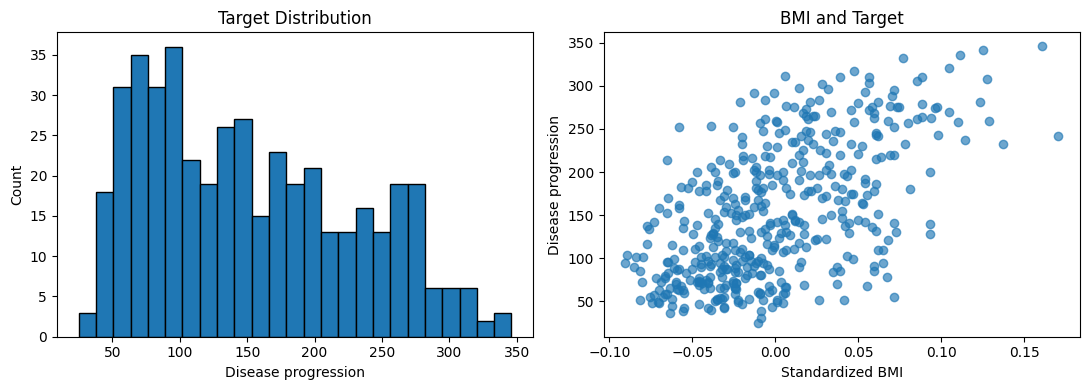

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(diabetes_df["target"], bins=25, edgecolor="black")
axes[0].set_xlabel("Disease progression")
axes[0].set_ylabel("Count")
axes[0].set_title("Target Distribution")

axes[1].scatter(diabetes_df["bmi"], diabetes_df["target"], alpha=0.65)
axes[1].set_xlabel("Standardized BMI")
axes[1].set_ylabel("Disease progression")
axes[1].set_title("BMI and Target")

plt.tight_layout()
plt.show()

## Classical linear regression

In [20]:
X_basic = diabetes.data
y_basic = diabetes.target

X_train_basic, X_test_basic, y_train_basic, y_test_basic = train_test_split(X_basic, y_basic, test_size=0.20, random_state=SEED)

model_linear_basic = LinearRegression()
print(model_linear_basic)

LinearRegression()


In [21]:
model_linear_basic.fit(X_train_basic, y_train_basic)

predictions_train_linear_basic = model_linear_basic.predict(X_train_basic)
predictions_test_linear_basic = model_linear_basic.predict(X_test_basic)

mse_train_linear_basic = mean_squared_error(y_train_basic, predictions_train_linear_basic)
mse_test_linear_basic = mean_squared_error(y_test_basic, predictions_test_linear_basic)
r2_test_linear_basic = r2_score(y_test_basic, predictions_test_linear_basic)

print(f"Intercept: {model_linear_basic.intercept_}")

display(pd.Series(
    model_linear_basic.coef_,
    index=diabetes.feature_names,
    name="coefficient"
).round(3))

print(f"Train MSE: {mse_train_linear_basic}")
print(f"Test MSE:  {mse_test_linear_basic}")
print(f"Test R²:   {r2_test_linear_basic}")

Intercept: 151.7555240418249


,coefficient
age,-114.582
sex,-236.946
bmi,532.448
bp,308.755
s1,-979.065
s2,606.159
s3,249.810
s4,300.737
s5,826.471
s6,111.397


Train MSE: 2772.9801919481456
Test MSE:  3361.3014054003124
Test R²:   0.425757647087306


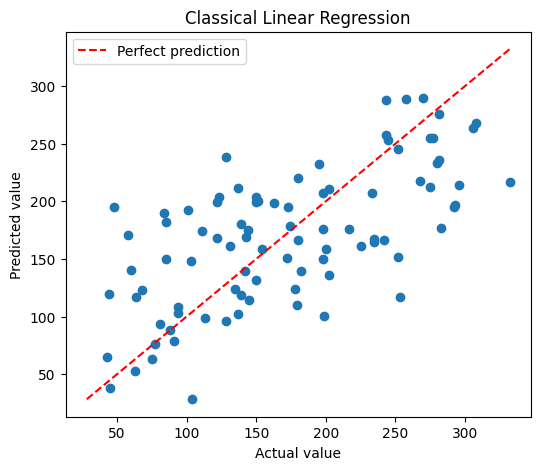

In [22]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test_basic, predictions_test_linear_basic)

minimum = min(y_test_basic.min(), predictions_test_linear_basic.min())
maximum = max(y_test_basic.max(), predictions_test_linear_basic.max())
plt.plot([minimum, maximum], [minimum, maximum], "r--", label="Perfect prediction")

plt.xlabel("Actual value")
plt.ylabel("Predicted value")
plt.title("Classical Linear Regression")
plt.legend()
plt.show()

## Neural-network regression on the same data


In [23]:
scaler_x_basic = StandardScaler()
scaler_y_basic = StandardScaler()

X_train_tensor_basic = torch.tensor(scaler_x_basic.fit_transform(X_train_basic), dtype=torch.float32)
X_test_tensor_basic = torch.tensor(scaler_x_basic.transform(X_test_basic), dtype=torch.float32)
#Scaler optional, address in patch notes
y_train_tensor_basic = torch.tensor(scaler_y_basic.fit_transform(y_train_basic.reshape(-1, 1)), dtype=torch.float32)
y_test_tensor_basic = torch.tensor(scaler_y_basic.transform(y_test_basic.reshape(-1, 1)), dtype=torch.float32)

In [24]:
class BasicRegressionNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        return self.fc2(x)


torch.manual_seed(SEED)
model_nn_basic = BasicRegressionNN(
    input_size=10,
    hidden_size=25,
    output_size=1
)
criterion_nn_basic = nn.MSELoss()
optimizer_nn_basic = torch.optim.Adam(
    model_nn_basic.parameters(),
    lr=0.001
)

print(model_nn_basic)

BasicRegressionNN(
  (fc1): Linear(in_features=10, out_features=25, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=25, out_features=1, bias=True)
)


In [25]:
history_nn_basic = []

for epoch in range(1000):
    predictions_nn_basic = model_nn_basic(X_train_tensor_basic)
    loss = criterion_nn_basic(predictions_nn_basic, y_train_tensor_basic)

    optimizer_nn_basic.zero_grad()
    loss.backward()
    optimizer_nn_basic.step()

    history_nn_basic.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/1000 | Loss: {loss.item()}")

Epoch 100/1000 | Loss: 0.5025678873062134
Epoch 200/1000 | Loss: 0.43460795283317566
Epoch 300/1000 | Loss: 0.4071834683418274
Epoch 400/1000 | Loss: 0.3918399214744568
Epoch 500/1000 | Loss: 0.38062000274658203
Epoch 600/1000 | Loss: 0.36912453174591064
Epoch 700/1000 | Loss: 0.356050044298172
Epoch 800/1000 | Loss: 0.34347760677337646
Epoch 900/1000 | Loss: 0.3312199115753174
Epoch 1000/1000 | Loss: 0.3186572194099426


In [26]:
model_nn_basic.eval()

with torch.no_grad():
    predictions_train_scaled_nn_basic = model_nn_basic(X_train_tensor_basic).numpy()
    predictions_test_scaled_nn_basic = model_nn_basic(X_test_tensor_basic).numpy()

predictions_train_nn_basic = scaler_y_basic.inverse_transform(predictions_train_scaled_nn_basic).ravel()
predictions_test_nn_basic = scaler_y_basic.inverse_transform(predictions_test_scaled_nn_basic).ravel()

mse_train_nn_basic = mean_squared_error(y_train_basic, predictions_train_nn_basic)
mse_test_nn_basic = mean_squared_error(y_test_basic, predictions_test_nn_basic)
r2_test_nn_basic = r2_score(y_test_basic, predictions_test_nn_basic)

print(f"Train MSE: {mse_train_nn_basic}")
print(f"Test MSE:  {mse_test_nn_basic}")
print(f"Test R²:   {r2_test_nn_basic}")

Train MSE: 1856.907830913774
Test MSE:  3470.406081271992
Test R²:   0.40711828148752016


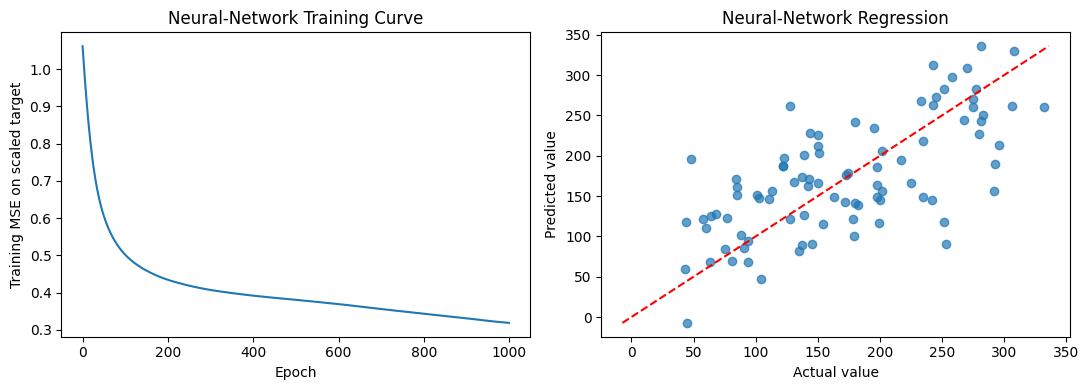

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_nn_basic)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training MSE on scaled target")
axes[0].set_title("Neural-Network Training Curve")

axes[1].scatter(y_test_basic, predictions_test_nn_basic, alpha=0.7)
minimum = min(y_test_basic.min(), predictions_test_nn_basic.min())
maximum = max(y_test_basic.max(), predictions_test_nn_basic.max())
axes[1].plot([minimum, maximum], [minimum, maximum], "r--")
axes[1].set_xlabel("Actual value")
axes[1].set_ylabel("Predicted value")
axes[1].set_title("Neural-Network Regression")

plt.tight_layout()
plt.show()

In [28]:
results_basic = pd.DataFrame({
    "Model": ["Classical linear regression", "Neural-network regression"],
    "Train MSE": [mse_train_linear_basic, mse_train_nn_basic],
    "Test MSE": [mse_test_linear_basic, mse_test_nn_basic],
    "Test R2": [r2_test_linear_basic, r2_test_nn_basic]
})

display(results_basic)

,Model,Train MSE,Test MSE,Test R2
0,Classical linear regression,2772.980192,3361.301405,0.425758
1,Neural-network regression,1856.907831,3470.406081,0.407118


# Part II: Challenging Regression with Penalties


## Create the challenging feature set

We add squared terms and pairwise interactions. This expands the original 10 predictors to 65 correlated predictors. The task is more flexible than ordinary ten-variable regression, but it is not placed artificially close to interpolation.

In [29]:
X_regression = diabetes.data
y_regression = diabetes.target

X_train_raw, X_test_raw, y_train_challenge, y_test_challenge = train_test_split(X_regression, y_regression, test_size=0.20, random_state=SEED)

transformer_poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = transformer_poly.fit_transform(X_train_raw)
X_test_poly = transformer_poly.transform(X_test_raw)

scaler_poly = StandardScaler()
X_train_challenge = scaler_poly.fit_transform(X_train_poly)
X_test_challenge = scaler_poly.transform(X_test_poly)

print("Training shape:", X_train_challenge.shape)
print("Test shape:", X_test_challenge.shape)

Training shape: (353, 65)
Test shape: (89, 65)


## Build the classical regression models

### Ridge, Lasso, and Elastic Net

**Ridge regression** adds an $L_2$ penalty:

$$
\operatorname{MSE} + \alpha \sum_{j=1}^{p}\beta_j^2.
$$


**Lasso regression** adds an $L_1$ penalty:

$$
\operatorname{MSE} + \alpha \sum_{j=1}^{p}|\beta_j|.
$$


**Elastic Net** combines $L_1$ and $L_2$ penalties:

$$
\operatorname{MSE}
+
\alpha\left[
\rho\sum_{j=1}^{p}|\beta_j|
+
(1-\rho)\sum_{j=1}^{p}\beta_j^2
\right].
$$


In [30]:
model_ols = LinearRegression()
model_ridge = Ridge(alpha=100.)
model_lasso = Lasso(alpha=1., max_iter=100000)
model_elastic = ElasticNet(alpha=1., l1_ratio=0.5, max_iter=100000)

## Fit and run each classical model

In [31]:
model_ols.fit(X_train_challenge, y_train_challenge)
predictions_train_ols = model_ols.predict(X_train_challenge)
predictions_test_ols = model_ols.predict(X_test_challenge)

mse_train_ols = mean_squared_error(y_train_challenge, predictions_train_ols)
mse_test_ols = mean_squared_error(y_test_challenge, predictions_test_ols)
r2_test_ols = r2_score(y_test_challenge, predictions_test_ols)

print(f"OLS train MSE: {mse_train_ols}")
print(f"OLS test MSE:  {mse_test_ols}")
print(f"OLS test R²:   {r2_test_ols}")

OLS train MSE: 2230.2233101368092
OLS test MSE:  3759.759890775567
OLS test R²:   0.3576852814814421


In [32]:
model_ridge.fit(X_train_challenge, y_train_challenge)
predictions_train_ridge = model_ridge.predict(X_train_challenge)
predictions_test_ridge = model_ridge.predict(X_test_challenge)

mse_train_ridge = mean_squared_error(y_train_challenge, predictions_train_ridge)
mse_test_ridge = mean_squared_error(y_test_challenge, predictions_test_ridge)
r2_test_ridge = r2_score(y_test_challenge, predictions_test_ridge)

print(f"Ridge train MSE: {mse_train_ridge}")
print(f"Ridge test MSE:  {mse_test_ridge}")
print(f"Ridge test R²:   {r2_test_ridge}")

Ridge train MSE: 2491.0341757376236
Ridge test MSE:  3252.906638212305
Ridge test R²:   0.4442757323900586


In [33]:
model_lasso.fit(X_train_challenge, y_train_challenge)
predictions_train_lasso = model_lasso.predict(X_train_challenge)
predictions_test_lasso = model_lasso.predict(X_test_challenge)

mse_train_lasso = mean_squared_error(y_train_challenge, predictions_train_lasso)
mse_test_lasso = mean_squared_error(y_test_challenge, predictions_test_lasso)
r2_test_lasso = r2_score(y_test_challenge, predictions_test_lasso)

print(f"Lasso train MSE: {mse_train_lasso}")
print(f"Lasso test MSE:  {mse_test_lasso}")
print(f"Lasso test R²:   {r2_test_lasso}")
print("Nonzero coefficients:", np.count_nonzero(model_lasso.coef_))

Lasso train MSE: 2446.734770597976
Lasso test MSE:  3210.628373731338
Lasso test R²:   0.45149852116871747
Nonzero coefficients: 39


In [34]:
model_elastic.fit(X_train_challenge, y_train_challenge)
predictions_train_elastic = model_elastic.predict(X_train_challenge)
predictions_test_elastic = model_elastic.predict(X_test_challenge)

mse_train_elastic = mean_squared_error(y_train_challenge, predictions_train_elastic)
mse_test_elastic = mean_squared_error(y_test_challenge, predictions_test_elastic)
r2_test_elastic = r2_score(y_test_challenge, predictions_test_elastic)

print(f"Elastic Net train MSE: {mse_train_elastic}")
print(f"Elastic Net test MSE:  {mse_test_elastic}")
print(f"Elastic Net test R²:   {r2_test_elastic}")

Elastic Net train MSE: 2668.4291732335923
Elastic Net test MSE:  3245.6276348040797
Elastic Net test R²:   0.4455192721801182


## Compare and visualize the classical regressions

In [35]:
results_regression_classical = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "Elastic Net"],
    "Penalty": ["None", "L2", "L1", "L1 + L2"],
    "Train MSE": [mse_train_ols, mse_train_ridge, mse_train_lasso, mse_train_elastic],
    "Test MSE": [mse_test_ols, mse_test_ridge, mse_test_lasso, mse_test_elastic],
    "Test R2": [r2_test_ols, r2_test_ridge, r2_test_lasso, r2_test_elastic]
})

display(results_regression_classical)

,Model,Penalty,Train MSE,Test MSE,Test R2
0,OLS,None,2230.223310,3759.759891,0.357685
1,Ridge,L2,2491.034176,3252.906638,0.444276
2,Lasso,L1,2446.734771,3210.628374,0.451499
3,Elastic Net,L1 + L2,2668.429173,3245.627635,0.445519


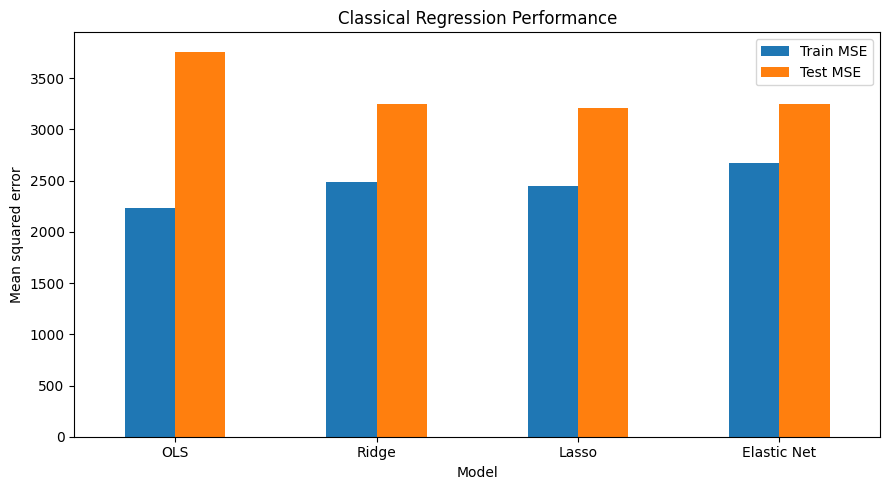

In [36]:
results_regression_classical.set_index("Model")[["Train MSE", "Test MSE"]].plot(
    kind="bar", figsize=(9, 5)
)
plt.ylabel("Mean squared error")
plt.title("Classical Regression Performance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

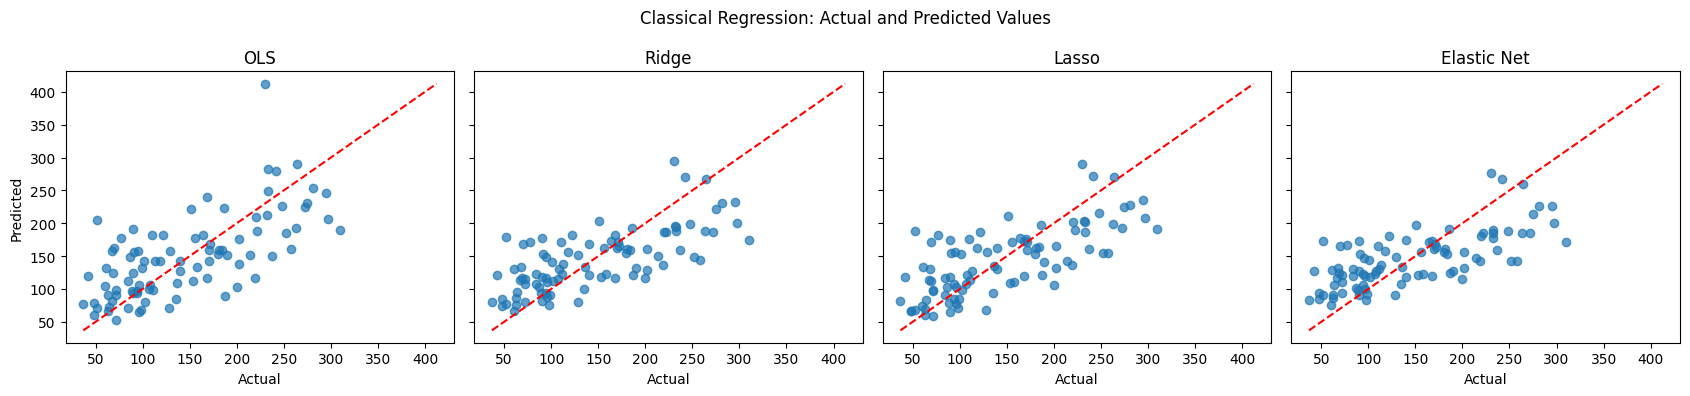

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharex=True, sharey=True)
model_names = ["OLS", "Ridge", "Lasso", "Elastic Net"]
prediction_sets = [
    predictions_test_ols,
    predictions_test_ridge,
    predictions_test_lasso,
    predictions_test_elastic
]

minimum = min(y_test_challenge.min(), *(pred.min() for pred in prediction_sets))
maximum = max(y_test_challenge.max(), *(pred.max() for pred in prediction_sets))

for ax, name, predictions in zip(axes, model_names, prediction_sets):
    ax.scatter(y_test_challenge, predictions, alpha=0.7)
    ax.plot([minimum, maximum], [minimum, maximum], "r--")
    ax.set_title(name)
    ax.set_xlabel("Actual")

axes[0].set_ylabel("Predicted")
plt.suptitle("Classical Regression: Actual and Predicted Values")
plt.tight_layout()
plt.show()

### Build the penalized neural-network regression models

In [ ]:
scaler_y_challenge = StandardScaler()
y_train_scaled_challenge = scaler_y_challenge.fit_transform(y_train_challenge.reshape(-1, 1)).astype(np.float32)
y_test_scaled_challenge = scaler_y_challenge.transform(y_test_challenge.reshape(-1, 1)).astype(np.float32)

X_train_tensor_challenge = torch.tensor(X_train_challenge, dtype=torch.float32)
X_test_tensor_challenge = torch.tensor(X_test_challenge, dtype=torch.float32)

y_train_tensor_challenge = torch.tensor(y_train_scaled_challenge, dtype=torch.float32)
y_test_tensor_challenge = torch.tensor(y_test_scaled_challenge, dtype=torch.float32)

In [ ]:
class RegressionNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        return self.fc2(x)

In [ ]:
torch.manual_seed(SEED)
model_nn_none = RegressionNN(X_train_challenge.shape[1], 64, 1)
criterion_nn_none = nn.MSELoss()
optimizer_nn_none = torch.optim.Adam(model_nn_none.parameters(), lr=0.001)

torch.manual_seed(SEED)
model_nn_l1 = RegressionNN(X_train_challenge.shape[1], 64, 1)
criterion_nn_l1 = nn.MSELoss()
optimizer_nn_l1 = torch.optim.Adam(model_nn_l1.parameters(), lr=0.001)

torch.manual_seed(SEED)
model_nn_l2 = RegressionNN(X_train_challenge.shape[1], 64, 1)
criterion_nn_l2 = nn.MSELoss()
optimizer_nn_l2 = torch.optim.Adam(model_nn_l2.parameters(), lr=0.001, weight_decay=1e-2)

print(model_nn_none)

RegressionNN(
  (fc1): Linear(in_features=65, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


## Train each penalized neural network explicitly

In [ ]:
history_nn_none = []

for epoch in range(1000):
    predictions = model_nn_none(X_train_tensor_challenge)
    loss = criterion_nn_none(predictions, y_train_tensor_challenge)

    optimizer_nn_none.zero_grad()
    loss.backward()
    optimizer_nn_none.step()

    history_nn_none.append(loss.item())

print(f"Final unpenalized training loss: {history_nn_none[-1]}")

Final unpenalized training loss: 0.0005705125513486564


In [ ]:
history_nn_l1 = []
lambda_l1 = 1e-3

for epoch in range(1000):
    predictions = model_nn_l1(X_train_tensor_challenge)
    mse = criterion_nn_l1(predictions, y_train_tensor_challenge)
    l1_penalty = (
        model_nn_l1.fc1.weight.abs().sum()
        + model_nn_l1.fc2.weight.abs().sum()
    )
    loss = mse + lambda_l1 * l1_penalty

    optimizer_nn_l1.zero_grad()
    loss.backward()
    optimizer_nn_l1.step()

    history_nn_l1.append(mse.item())

print(f"Final L1 training MSE: {history_nn_l1[-1]}")

Final L1 training MSE: 0.023778315633535385


In [ ]:
history_nn_l2 = []

for epoch in range(1000):
    predictions = model_nn_l2(X_train_tensor_challenge)
    loss = criterion_nn_l2(predictions, y_train_tensor_challenge)

    optimizer_nn_l2.zero_grad()
    loss.backward()
    optimizer_nn_l2.step()

    history_nn_l2.append(loss.item())

print(f"Final L2 training loss: {history_nn_l2[-1]}")

Final L2 training loss: 0.026890713721513748


In [ ]:
model_nn_none.eval()
model_nn_l1.eval()
model_nn_l2.eval()

with torch.no_grad():
    predictions_train_scaled_nn_none = model_nn_none(X_train_tensor_challenge).numpy()
    predictions_test_scaled_nn_none = model_nn_none(X_test_tensor_challenge).numpy()

    predictions_train_scaled_nn_l1 = model_nn_l1(X_train_tensor_challenge).numpy()
    predictions_test_scaled_nn_l1 = model_nn_l1(X_test_tensor_challenge).numpy()

    predictions_train_scaled_nn_l2 = model_nn_l2(X_train_tensor_challenge).numpy()
    predictions_test_scaled_nn_l2 = model_nn_l2(X_test_tensor_challenge).numpy()

predictions_train_nn_none = scaler_y_challenge.inverse_transform(predictions_train_scaled_nn_none).ravel()
predictions_test_nn_none = scaler_y_challenge.inverse_transform(predictions_test_scaled_nn_none).ravel()

predictions_train_nn_l1 = scaler_y_challenge.inverse_transform(predictions_train_scaled_nn_l1).ravel()
predictions_test_nn_l1 = scaler_y_challenge.inverse_transform(predictions_test_scaled_nn_l1).ravel()

predictions_train_nn_l2 = scaler_y_challenge.inverse_transform(predictions_train_scaled_nn_l2).ravel()
predictions_test_nn_l2 = scaler_y_challenge.inverse_transform(predictions_test_scaled_nn_l2).ravel()

In [ ]:
results_nn = pd.DataFrame({
    "Model": ["NN: none", "NN: L1", "NN: L2"],
    "Train MSE": [
        mean_squared_error(y_train_challenge, predictions_train_nn_none),
        mean_squared_error(y_train_challenge, predictions_train_nn_l1),
        mean_squared_error(y_train_challenge, predictions_train_nn_l2)
    ],
    "Test MSE": [
        mean_squared_error(y_test_challenge, predictions_test_nn_none),
        mean_squared_error(y_test_challenge, predictions_test_nn_l1),
        mean_squared_error(y_test_challenge, predictions_test_nn_l2)
    ],
    "Test R2": [
        r2_score(y_test_challenge, predictions_test_nn_none),
        r2_score(y_test_challenge, predictions_test_nn_l1),
        r2_score(y_test_challenge, predictions_test_nn_l2)
    ]
})

display(results_nn)

,Model,Train MSE,Test MSE,Test R2
0,NN: none,3.438849,7326.256339,-0.382795
1,NN: L1,144.233854,5040.416121,0.048646
2,NN: L2,162.983796,4006.028634,0.243882


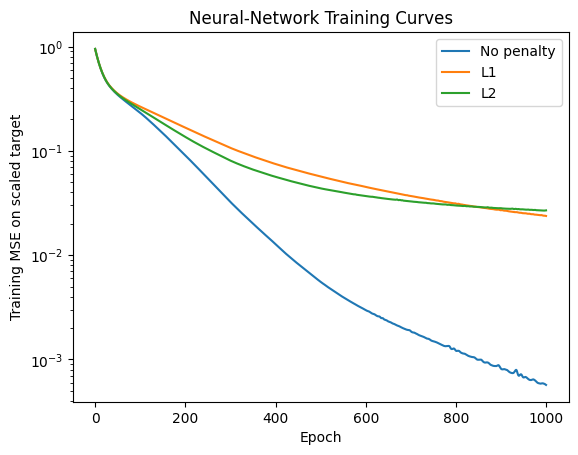

In [ ]:
plt.plot(history_nn_none, label="No penalty")
plt.plot(history_nn_l1, label="L1")
plt.plot(history_nn_l2, label="L2")
plt.xlabel("Epoch")
plt.ylabel("Training MSE on scaled target")
plt.title("Neural-Network Training Curves")
plt.legend()
plt.yscale("log")
plt.show()

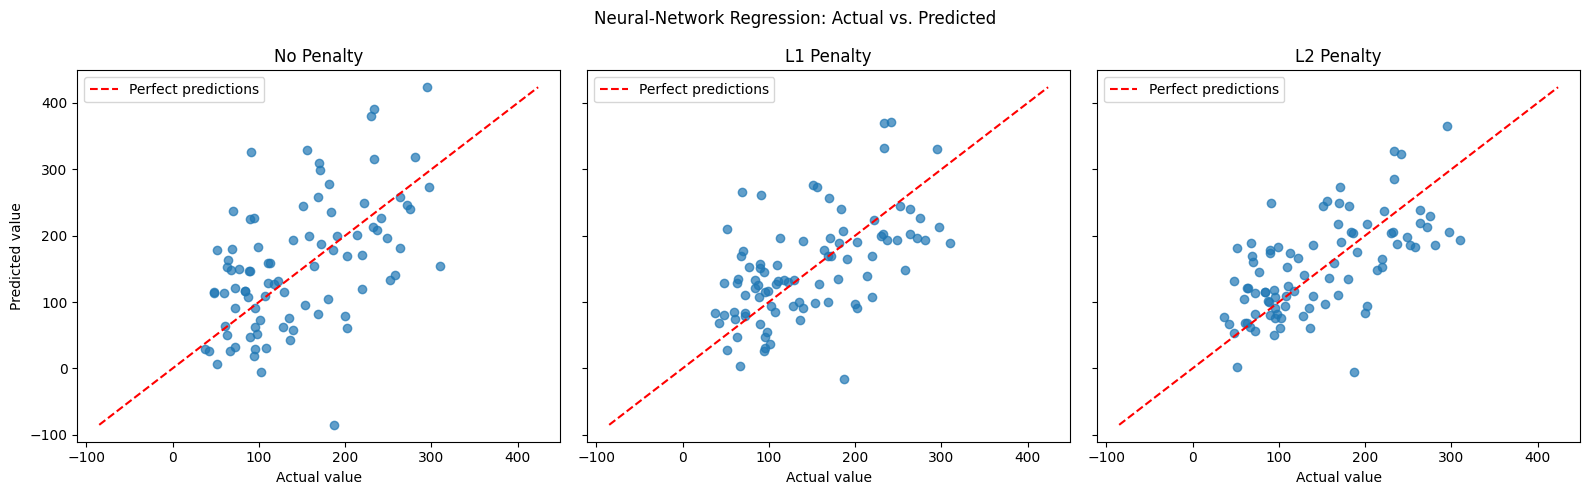

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

prediction_sets = [
    predictions_test_nn_none,
    predictions_test_nn_l1,
    predictions_test_nn_l2
]

model_names = [
    "No Penalty",
    "L1 Penalty",
    "L2 Penalty"
]

minimum = min(
    y_test_challenge.min(),
    *(predictions.min() for predictions in prediction_sets)
)

maximum = max(
    y_test_challenge.max(),
    *(predictions.max() for predictions in prediction_sets)
)

for ax, predictions, name in zip(axes, prediction_sets, model_names):
    ax.scatter(
        y_test_challenge,
        predictions,
        alpha=0.7
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        color="red",
        linestyle="--",
        label="Perfect predictions"
    )

    ax.set_title(name)
    ax.set_xlabel("Actual value")
    ax.legend()

axes[0].set_ylabel("Predicted value")

plt.suptitle("Neural-Network Regression: Actual vs. Predicted")
plt.tight_layout()
plt.show()

In [ ]:
results_regression_combined = pd.concat([
    results_regression_classical[["Model", "Train MSE", "Test MSE", "Test R2"]],
    results_nn
], ignore_index=True)

display(results_regression_combined.sort_values("Test MSE"))

,Model,Train MSE,Test MSE,Test R2
2,Lasso,2630.037680,2563.881379,0.516080
1,Ridge,2668.831295,2659.112363,0.498106
3,Elastic Net,2827.627152,2772.301179,0.476742
0,OLS,2393.138618,3096.028307,0.415640
6,NN: L2,162.983796,4006.028634,0.243882
5,NN: L1,144.233854,5040.416121,0.048646
4,NN: none,3.438849,7326.256339,-0.382795


# Part III: Multiclass Classification with Softmax

## Load and inspect the data

The Digits dataset contains 1,797 handwritten $8\times8$ images. Each row contains 64 pixel intensities, and the target is one of ten classes: 0 through 9.

In [ ]:
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

digits_df = pd.DataFrame(X_digits, columns=digits.feature_names)
digits_df["target"] = y_digits

print("Shape:", digits_df.shape)
print("Class counts:", np.bincount(y_digits))
display(digits_df.head())

Shape: (1797, 65)
Class counts: [178 182 177 183 181 182 181 179 174 180]


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


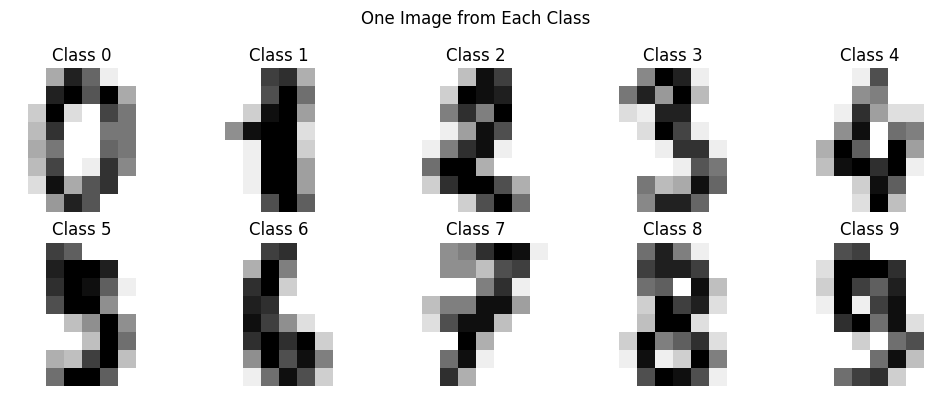

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, ax in enumerate(axes.ravel()):
    example = np.flatnonzero(y_digits == digit)[0]
    ax.imshow(digits.images[example], cmap="gray_r")
    ax.set_title(f"Class {digit}")
    ax.axis("off")

plt.suptitle("One Image from Each Class")
plt.tight_layout()
plt.show()

In [ ]:
X_train_digits, X_test_digits, y_train_digits, y_test_digits = train_test_split(
    X_digits,
    y_digits,
    test_size=0.20,
    random_state=SEED,
    stratify=y_digits
)

scaler_digits = StandardScaler()
X_train_scaled_digits = scaler_digits.fit_transform(X_train_digits)
X_test_scaled_digits = scaler_digits.transform(X_test_digits)

## Build and run classical softmax regression

For class $k$, the model builds a logit $z_k=w_k^Tx+b_k$. Softmax converts the ten logits into probabilities:

$$P(Y=k\mid x)=\frac{e^{z_k}}{\sum_{j=1}^{10}e^{z_j}}.$$

The parameter `C=1.0` is the inverse regularization strength. The `lbfgs` solver estimates the coefficient matrix and intercepts.

In [ ]:
model_softmax = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=5000,
    random_state=SEED
)

print(model_softmax)

LogisticRegression(max_iter=5000, random_state=42)


In [ ]:
model_softmax.fit(X_train_scaled_digits, y_train_digits)

predictions_train_softmax = model_softmax.predict(X_train_scaled_digits)
predictions_test_softmax = model_softmax.predict(X_test_scaled_digits)
probabilities_test_softmax = model_softmax.predict_proba(X_test_scaled_digits)

accuracy_train_softmax = accuracy_score(y_train_digits, predictions_train_softmax)
accuracy_test_softmax = accuracy_score(y_test_digits, predictions_test_softmax)
loss_test_softmax = log_loss(y_test_digits, probabilities_test_softmax)

print(f"Train accuracy: {accuracy_train_softmax}")
print(f"Test accuracy: {accuracy_test_softmax}")
print(f"Test cross-entropy: {loss_test_softmax}")

Train accuracy: 0.9993041057759221
Test accuracy: 0.9722222222222222
Test cross-entropy: 0.10195007619518374


### Inspect the learned classical parameters

The model learns 10 coefficient vectors with 64 entries each, plus 10 intercepts. Each coefficient vector can be reshaped into an $8\times8$ image.

In [ ]:
print("Coefficient shape:", model_softmax.coef_.shape)
print("Intercept shape:", model_softmax.intercept_.shape)

coefficients_softmax = pd.DataFrame(
    model_softmax.coef_.T,
    index=digits.feature_names,
    columns=[f"class_{k}" for k in digits.target_names]
)
display(coefficients_softmax)
display(pd.Series(model_softmax.intercept_, name="intercept"))

Coefficient shape: (10, 64)
Intercept shape: (10,)


,class_0,class_1,class_2,class_3,class_4,class_5,class_6,class_7,class_8,class_9
pixel_0_0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
pixel_0_1,-0.053638,0.059195,0.006542,0.353612,-0.297177,0.380185,-0.084024,0.140392,-0.209816,-0.295271
pixel_0_2,-0.022329,-0.016033,-0.024871,-0.456325,-0.428409,0.942496,-0.386324,0.212602,0.302598,-0.123404
pixel_0_3,0.165085,0.212050,0.130671,0.142177,-0.928147,-0.375080,-0.133150,0.163348,-0.218474,0.841519
pixel_0_4,-0.011130,-0.980449,0.180100,0.995693,-0.751530,0.096623,-0.168696,0.270428,0.054413,0.314548
...,...,...,...,...,...,...,...,...,...,...
pixel_7_3,0.191830,-0.062153,0.250684,0.273659,-0.632198,0.768166,-0.225549,-0.573819,-0.018009,0.027388
pixel_7_4,-0.114672,0.065568,0.075938,0.190400,-0.431383,0.033814,0.055756,-0.760360,0.593057,0.291883
pixel_7_5,-0.088513,0.504189,0.539754,0.011467,-0.612097,0.059616,0.590379,-0.868517,-0.172944,0.036666
pixel_7_6,-0.148110,0.426730,0.742750,0.236295,-0.304957,-0.691789,0.132165,-0.252475,-0.277351,0.136743


,intercept
0,-0.298260
1,-0.832709
2,-0.164490
3,0.075945
4,-0.504596
5,0.345738
6,-0.549090
7,0.105646
8,1.984586
9,-0.162768


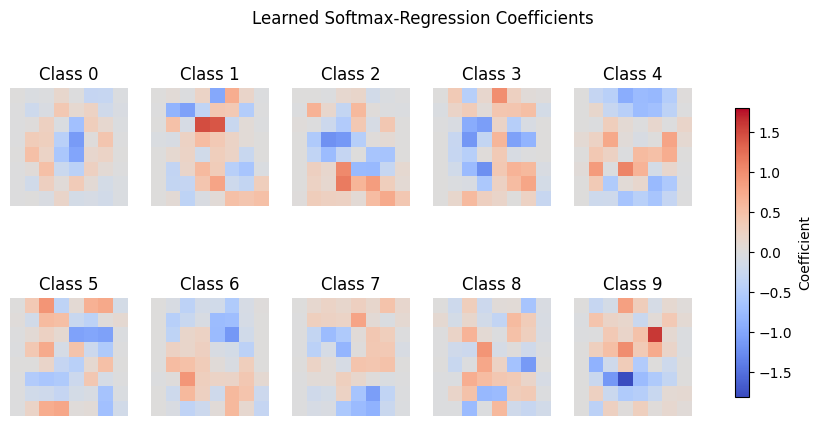

In [ ]:
limit = np.abs(model_softmax.coef_).max()
fig, axes = plt.subplots(2, 5, figsize=(11, 5))

for digit, ax in enumerate(axes.ravel()):
    image = ax.imshow(
        model_softmax.coef_[digit].reshape(8, 8),
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit
    )
    ax.set_title(f"Class {digit}")
    ax.axis("off")

fig.colorbar(image, ax=axes, shrink=0.75, label="Coefficient")
plt.suptitle("Learned Softmax-Regression Coefficients")
plt.show()

In [ ]:
class DigitNN(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size_1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size_1, hidden_size_2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size_2, output_size)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)

In [ ]:
X_train_tensor_digits = torch.tensor(X_train_scaled_digits, dtype=torch.float32)
X_test_tensor_digits = torch.tensor(X_test_scaled_digits, dtype=torch.float32)
y_train_tensor_digits = torch.tensor(y_train_digits, dtype=torch.long)
y_test_tensor_digits = torch.tensor(y_test_digits, dtype=torch.long)

torch.manual_seed(SEED)
model_nn_multiclass = DigitNN(64, 128, 64, 10)
criterion_nn_multiclass = nn.CrossEntropyLoss()
optimizer_nn_multiclass = torch.optim.Adam(model_nn_multiclass.parameters(), lr=0.001)

print(model_nn_multiclass)

DigitNN(
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [ ]:
history_nn_multiclass = []

for epoch in range(200):
    logits = model_nn_multiclass(X_train_tensor_digits)
    loss = criterion_nn_multiclass(logits, y_train_tensor_digits)

    optimizer_nn_multiclass.zero_grad()
    loss.backward()
    optimizer_nn_multiclass.step()

    history_nn_multiclass.append(loss.item())

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch + 1}/200 | Loss: {loss.item()}")

Epoch 25/200 | Loss: 1.3762683868408203
Epoch 50/200 | Loss: 0.40395480394363403
Epoch 75/200 | Loss: 0.14537085592746735
Epoch 100/200 | Loss: 0.07108913362026215
Epoch 125/200 | Loss: 0.04000674560666084
Epoch 150/200 | Loss: 0.02461225353181362
Epoch 175/200 | Loss: 0.016265861690044403
Epoch 200/200 | Loss: 0.011433389969170094


In [ ]:
model_nn_multiclass.eval()

with torch.no_grad():
    logits_train_nn_multiclass = model_nn_multiclass(X_train_tensor_digits)
    logits_test_nn_multiclass = model_nn_multiclass(X_test_tensor_digits)
    probabilities_test_nn_multiclass = torch.softmax(logits_test_nn_multiclass, dim=1)

predictions_train_nn_multiclass = logits_train_nn_multiclass.argmax(dim=1).numpy()
predictions_test_nn_multiclass = probabilities_test_nn_multiclass.argmax(dim=1).numpy()

accuracy_train_nn_multiclass = accuracy_score(y_train_digits, predictions_train_nn_multiclass)
accuracy_test_nn_multiclass = accuracy_score(y_test_digits, predictions_test_nn_multiclass)
loss_test_nn_multiclass = log_loss(y_test_digits, probabilities_test_nn_multiclass.numpy())

print(f"Train accuracy: {accuracy_train_nn_multiclass}")
print(f"Test accuracy: {accuracy_test_nn_multiclass}")
print(f"Test cross-entropy: {loss_test_nn_multiclass}")

Train accuracy: 1.0
Test accuracy: 0.9694444444444444
Test cross-entropy: 0.10301094365221479


In [ ]:
for parameter_name, parameter in model_nn_multiclass.named_parameters():
    print(
        f"{parameter_name:12s} "
        f"shape={tuple(parameter.shape)!s:12s} "
        f"parameters = {parameter.numel():5d} "
        f"norm = {parameter.detach().norm().item()}"
    )

print("Total parameters:", sum(p.numel() for p in model_nn_multiclass.parameters()))

fc1.weight   shape=(128, 64)    parameters =  8192 norm = 9.616189956665039
fc1.bias     shape=(128,)       parameters =   128 norm = 1.2257999181747437
fc2.weight   shape=(64, 128)    parameters =  8192 norm = 8.04586410522461
fc2.bias     shape=(64,)        parameters =    64 norm = 0.654844343662262
fc3.weight   shape=(10, 64)     parameters =   640 norm = 3.4873552322387695
fc3.bias     shape=(10,)        parameters =    10 norm = 0.25308936834335327
Total parameters: 17226


In [ ]:
results_classification = pd.DataFrame({
    "Model": ["Classical softmax regression", "Neural network"],
    "Train accuracy": [accuracy_train_softmax, accuracy_train_nn_multiclass],
    "Test accuracy": [accuracy_test_softmax, accuracy_test_nn_multiclass],
    "Test cross-entropy": [loss_test_softmax, loss_test_nn_multiclass]
})

display(results_classification)

,Model,Train accuracy,Test accuracy,Test cross-entropy
0,Classical softmax regression,0.999304,0.972222,0.101950
1,Neural network,1.000000,0.969444,0.103011


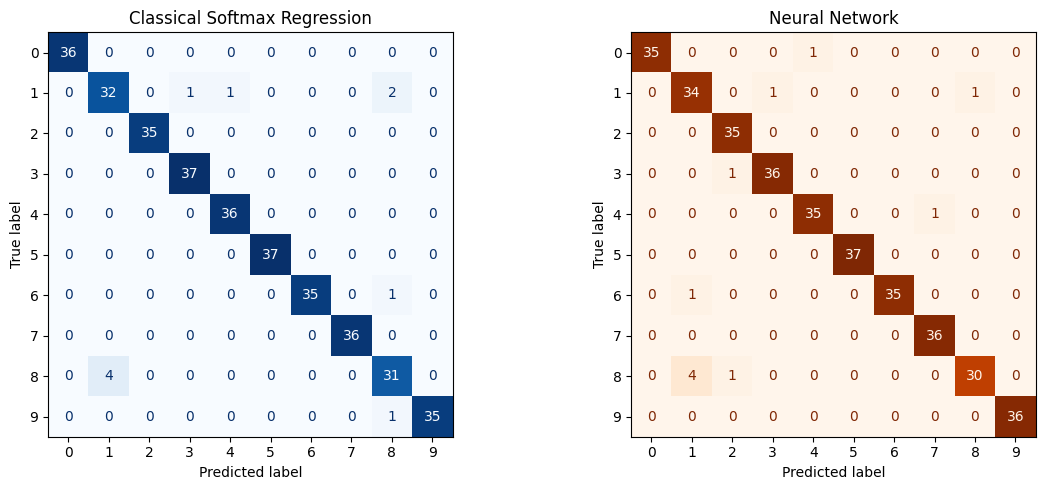

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_digits,
    predictions_test_softmax,
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)
axes[0].set_title("Classical Softmax Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test_digits,
    predictions_test_nn_multiclass,
    ax=axes[1],
    cmap="Oranges",
    colorbar=False
)
axes[1].set_title("Neural Network")

plt.tight_layout()
plt.show()

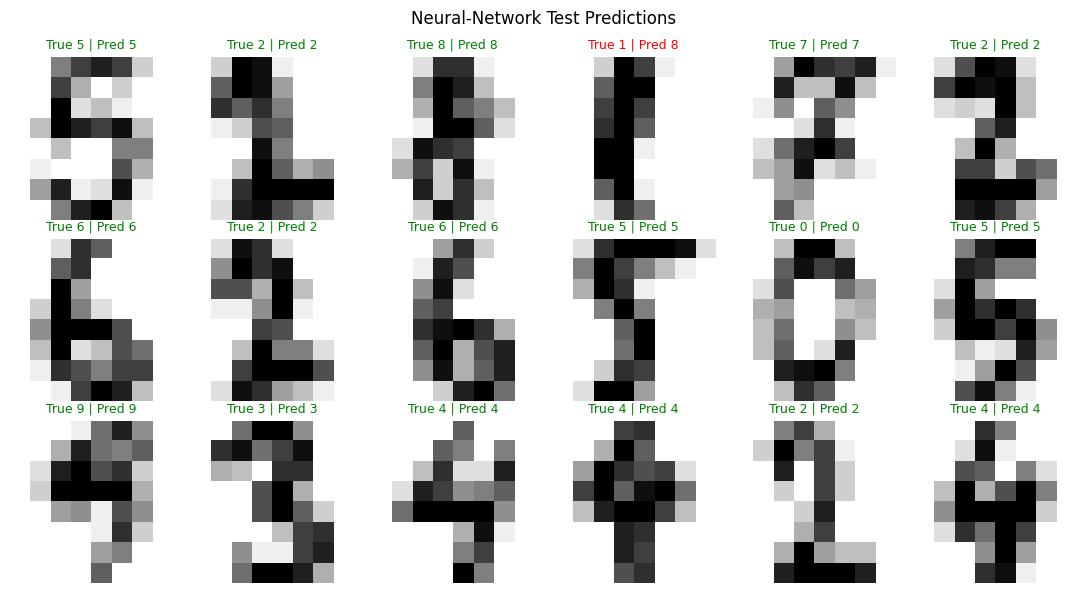

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(11, 6))

for index, ax in enumerate(axes.ravel()):
    ax.imshow(X_test_digits[index].reshape(8, 8), cmap="gray_r")
    actual = y_test_digits[index]
    predicted = predictions_test_nn_multiclass[index]
    color = "green" if actual == predicted else "red"
    ax.set_title(f"True {actual} | Pred {predicted}", color=color, fontsize=9)
    ax.axis("off")

plt.suptitle("Neural-Network Test Predictions")
plt.tight_layout()
plt.show()